In [68]:
import pandas as pd


asw_path = '/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/case/cell_emb/regformer_emb.csv'
df = pd.read_csv(asw_path)
df
df['dataset'] = [i.split('_')[-1] for i in df['Name']]
df['model'] = [i.split('_blood')[0].split('cell_emb_')[-1] for i in df['Name']]
df

,Name,test/aws,dataset,model
0,cell_emb_value_embedding_blood4,0.468063,blood4,value_embedding
1,cell_emb_value_embedding_blood3,0.452319,blood3,value_embedding
2,cell_emb_value_embedding_blood2,0.433632,blood2,value_embedding
3,cell_emb_value_embedding_blood1,0.468062,blood1,value_embedding
4,cell_emb_bin_cls_blood4,0.380379,blood4,bin_cls
5,cell_emb_bin_cls_blood3,0.375816,blood3,bin_cls
6,cell_emb_bin_cls_blood2,0.376127,blood2,bin_cls
7,cell_emb_bin_cls_blood1,0.319117,blood1,bin_cls
8,cell_emb_random_graph_sort_blood4,0.543531,blood4,random_graph_sort
9,cell_emb_random_graph_sort_blood3,0.536291,blood3,random_graph_sort


/tmp/ipykernel_2080703/3262058196.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_df, x='model', y='test/aws', ax=ax, palette=colors)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_g

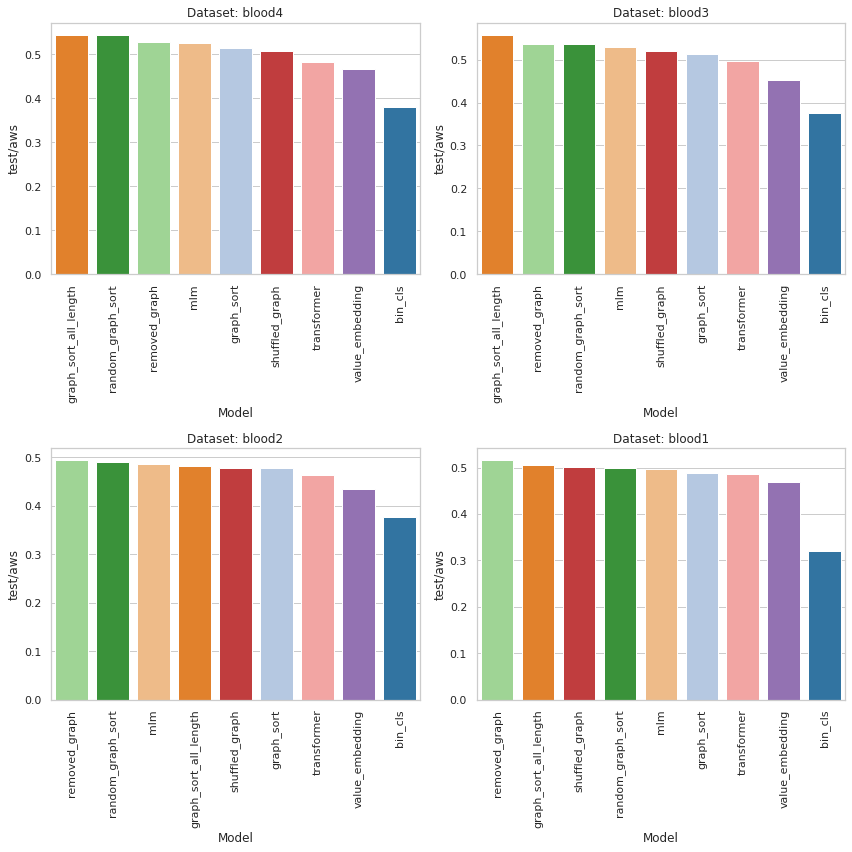

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

# 自定义模型颜色映射
unique_models = df['model'].unique()
unique_models.sort()
palette = sns.color_palette("tab20", len(unique_models))
model_palette = dict(zip(unique_models, palette))

# 画成两行子图
datasets = df['dataset'].unique()
n = len(datasets)
ncols = math.ceil(n / 2)  # 每行的图数
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows), squeeze=False)

for i, dataset in enumerate(datasets):
    row = i // ncols
    col = i % ncols
    ax = axes[row][col]

    sub_df = df[df['dataset'] == dataset].copy()
    sub_df = sub_df.sort_values(by='test/aws', ascending=False)

    colors = sub_df['model'].map(model_palette).tolist()
    sns.barplot(data=sub_df, x='model', y='test/aws', ax=ax, palette=colors)

    ax.set_title(f"Dataset: {dataset}")
    ax.set_ylabel("test/aws")
    ax.set_xlabel("Model")
    ax.tick_params(axis='x', rotation=90)

# 如果子图不足，会有空格，这里把空图删掉
for j in range(n, nrows * ncols):
    fig.delaxes(axes[j // ncols][j % ncols])

plt.tight_layout()
plt.show()


In [72]:
import pandas as pd


asw_path = '/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/case/Cell_annotation/regformer_anno.csv.blood4'
df = pd.read_csv(asw_path)
df = df[df.Name.str.contains('ep40')]
df['dataset'] = [i.split('_')[-4] for i in df['Name']]
df['model'] = [i.split('_blood')[0].split('anno_')[-1] for i in df['Name']]
df.fillna(0.1, inplace=True)
df

,Name,State,test/accuracy,test/macro_f1,test/recall,test/precision,bin_cls,dataset,model
0,anno_value_embedding_blood4_ep40_lr0.0001_2025...,finished,0.159043,0.141037,0.203408,0.232447,0.1,blood4,value_embedding
1,anno_bin_cls_blood4_ep40_lr0.0001_2025-05-29,finished,0.455308,0.366828,0.432358,0.412275,True,blood4,bin_cls
2,anno_transformer_blood4_ep40_lr0.0001_2025-05-29,finished,0.779689,0.731263,0.796178,0.744514,0.1,blood4,transformer
3,anno_shuffled_graph_blood4_ep40_lr0.0001_2025-...,finished,0.816198,0.755643,0.779541,0.768631,0.1,blood4,shuffled_graph
4,anno_removed_graph_blood4_ep40_lr0.0001_2025-0...,finished,0.846832,0.798355,0.814596,0.800422,0.1,blood4,removed_graph
5,anno_random_graph_sort_blood4_ep40_lr0.0001_20...,finished,0.733529,0.605294,0.658029,0.664164,0.1,blood4,random_graph_sort
6,anno_mlm_blood4_ep40_lr0.0001_2025-05-29,finished,0.845153,0.792847,0.815833,0.799181,0.1,blood4,mlm
7,anno_graph_sort_blood4_ep40_lr0.0001_2025-05-29,finished,0.831305,0.773189,0.802686,0.768774,0.1,blood4,graph_sort
8,anno_graph_sort_all_length_blood4_ep40_lr0.000...,finished,0.775913,0.590744,0.602318,0.666990,0.1,blood4,graph_sort_all_length


In [63]:
unique_models.sort()
unique_models

array(['bin_cls', 'graph_sort', 'graph_sort_all_length', 'mlm',
       'random_graph_sort', 'removed_graph', 'shuffled_graph',
       'transformer', 'value_embedding'], dtype=object)

/tmp/ipykernel_2080703/1100283443.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_metric_df, x='model', y=metric, ax=ax, palette=colors)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.ge

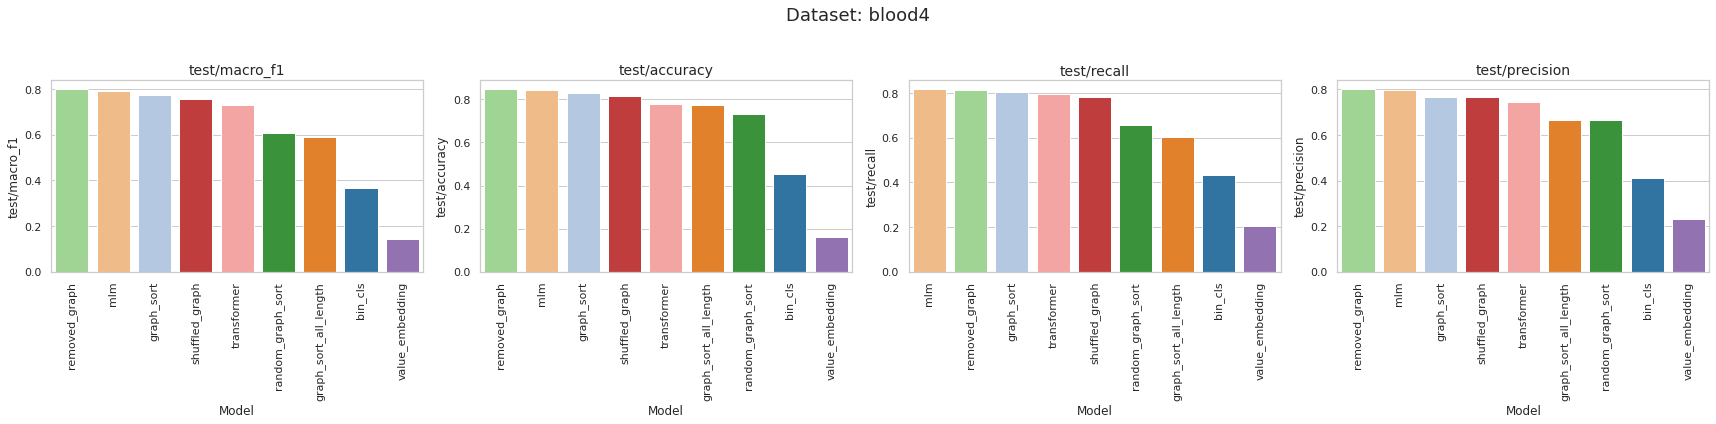

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 示例数据（假设 df 已定义）
# df 应包含：['dataset', 'model', 'test/macro_f1', 'test/accuracy', 'test/recall', 'test/precision']

# 自定义模型颜色映射
unique_models = df['model'].unique()
unique_models.sort()
palette = sns.color_palette("tab20", len(unique_models))
model_palette = dict(zip(unique_models, palette))

# 要画的指标
metrics = ['test/macro_f1', 'test/accuracy', 'test/recall', 'test/precision']

# 每个数据集一页
datasets = df['dataset'].unique()

for dataset in datasets:
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))  # 1行4列

    sub_df = df[df['dataset'] == dataset].copy()

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        sub_metric_df = sub_df.sort_values(by=metric, ascending=False)

        colors = sub_metric_df['model'].map(model_palette).tolist()
        sns.barplot(data=sub_metric_df, x='model', y=metric, ax=ax, palette=colors)

        ax.set_title(f"{metric}", fontsize=14)
        ax.set_ylabel(metric)
        ax.set_xlabel("Model")
        ax.tick_params(axis='x', rotation=90)

    fig.suptitle(f"Dataset: {dataset}", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # 留出标题空间
    plt.show()


/tmp/ipykernel_2080703/2355205452.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_df, x='model', y=metric, ax=ax, palette=colors)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group

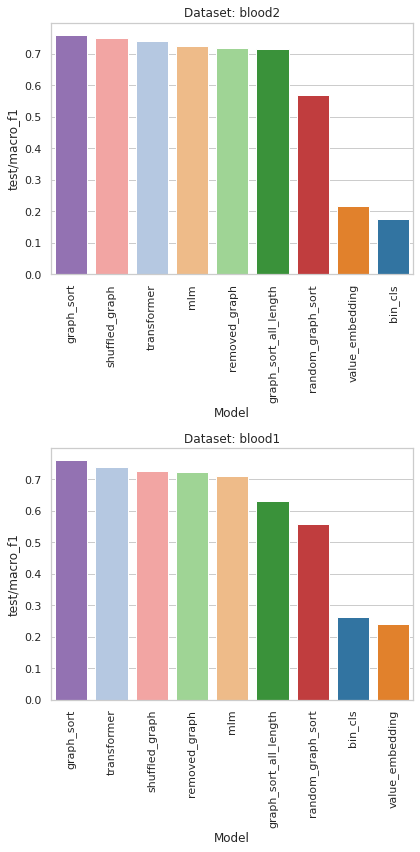

/tmp/ipykernel_2080703/2355205452.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_df, x='model', y=metric, ax=ax, palette=colors)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group

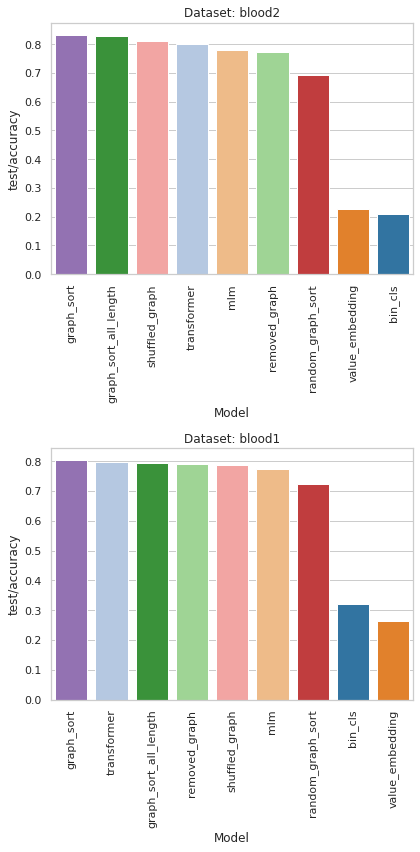

/tmp/ipykernel_2080703/2355205452.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_df, x='model', y=metric, ax=ax, palette=colors)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group

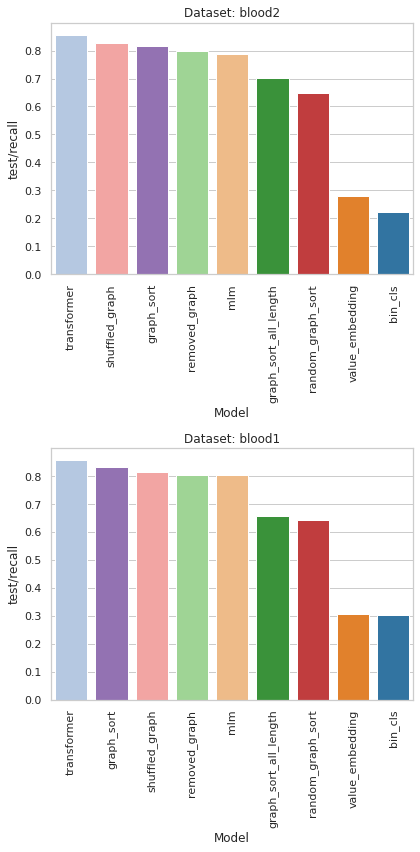

/tmp/ipykernel_2080703/2355205452.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_df, x='model', y=metric, ax=ax, palette=colors)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group

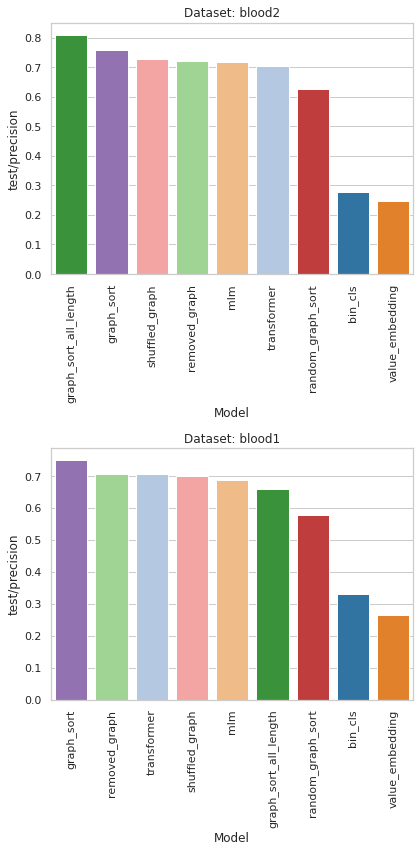

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

# 自定义模型颜色映射
unique_models = df['model'].unique()
palette = sns.color_palette("tab20", len(unique_models))
model_palette = dict(zip(unique_models, palette))

# 画成两行子图
datasets = df['dataset'].unique()
n = len(datasets)
ncols = math.ceil(n / 2)  # 每行的图数
nrows = 2

for metric in ['test/macro_f1', 'test/accuracy', 'test/recall', 'test/precision']:
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows), squeeze=False)

    for i, dataset in enumerate(datasets):
        row = i // ncols
        col = i % ncols
        ax = axes[row][col]

        sub_df = df[df['dataset'] == dataset].copy()
        sub_df = sub_df.sort_values(by=metric, ascending=False)

        colors = sub_df['model'].map(model_palette).tolist()
        sns.barplot(data=sub_df, x='model', y=metric, ax=ax, palette=colors)

        ax.set_title(f"Dataset: {dataset}")
        ax.set_ylabel(metric)
        ax.set_xlabel("Model")
        ax.tick_params(axis='x', rotation=90)

    # 如果子图不足，会有空格，这里把空图删掉
    for j in range(n, nrows * ncols):
        fig.delaxes(axes[j // ncols][j % ncols])

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_2080703/555474020.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_metric_df, x='model', y=metric, ax=ax, palette=colors)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get

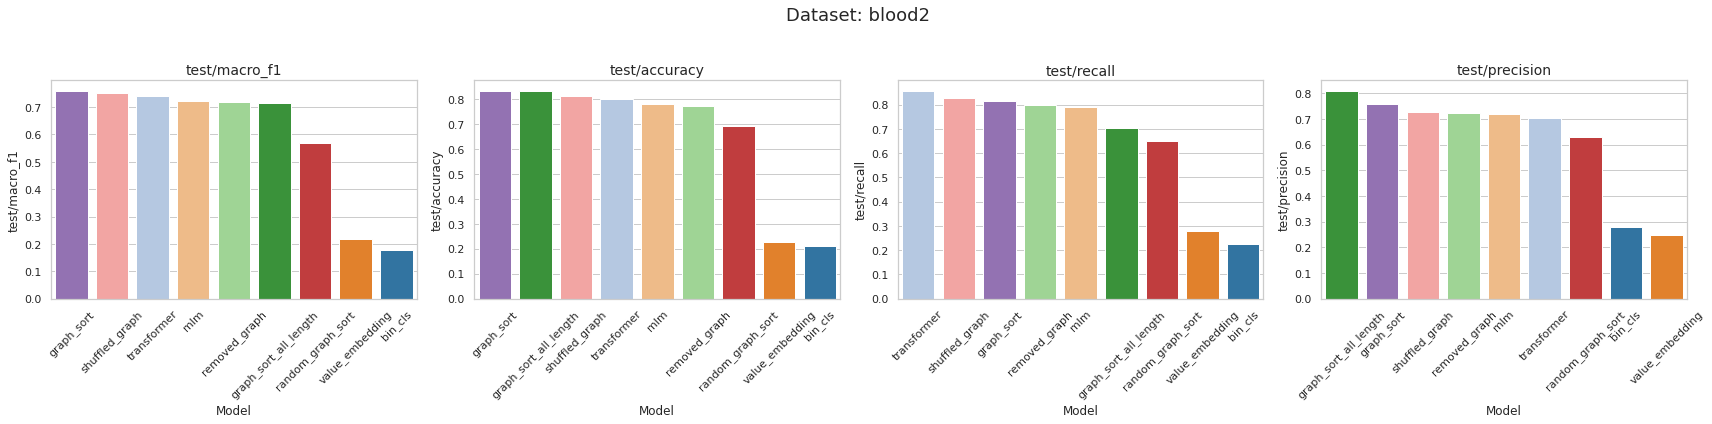

/tmp/ipykernel_2080703/555474020.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_metric_df, x='model', y=metric, ax=ax, palette=colors)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/share/huadjyin/home/s_qiuping1/app/miniconda3/envs/scgpt/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get

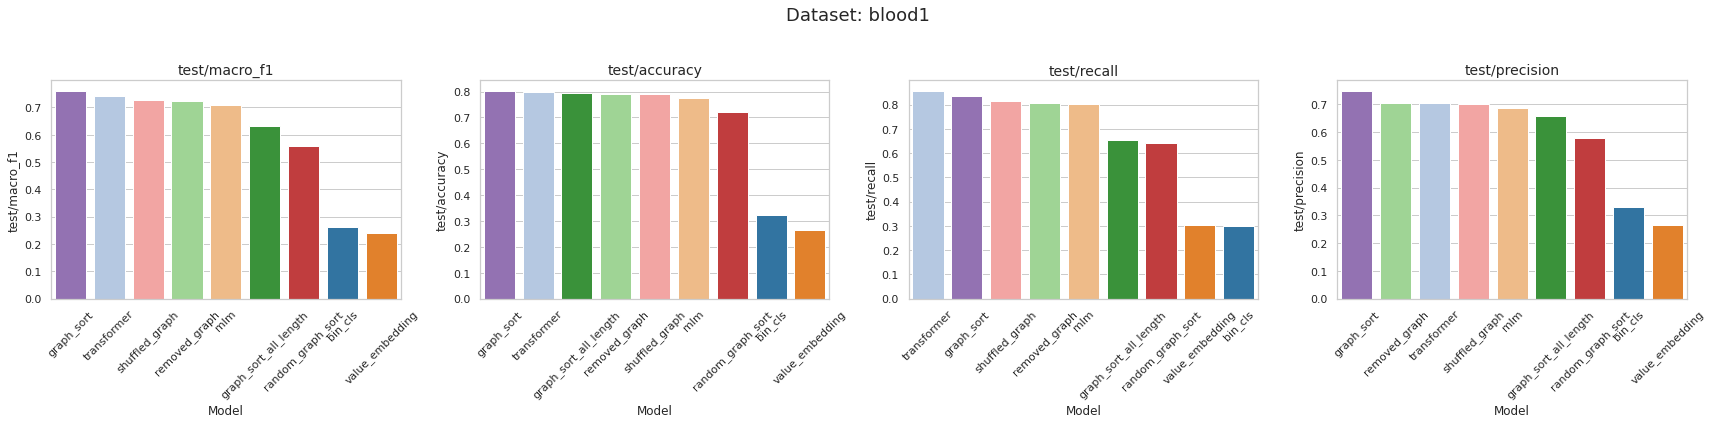